# کتابخانه های مورد نیاز

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import OneHotEncoder ,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier

# فراخوانی داده ها 

In [2]:
df = pd.read_csv('bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


# بررسی مقادیر گم شده 

In [3]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

# EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df['deposit'].value_counts(normalize=True)

deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64

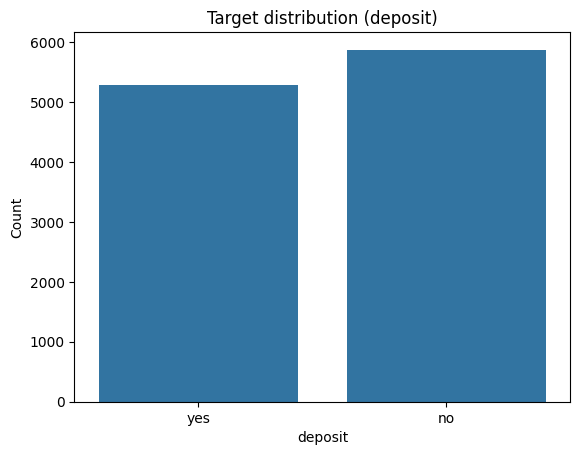

In [6]:
sns.countplot(data=df, x='deposit')
plt.title('Target distribution (deposit)')
plt.ylabel('Count');

In [7]:
df[['age','balance','duration']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.0,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.0,81204.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.0,3881.0


In [8]:
job_dis = df.groupby('job')['deposit'].value_counts(normalize=True).unstack()
contact_dis =df.groupby('contact')['deposit'].value_counts(normalize=True).unstack()
print(job_dis)
print('-'*100)
print(contact_dis)

deposit              no       yes
job                              
admin.         0.526987  0.473013
blue-collar    0.635802  0.364198
entrepreneur   0.625000  0.375000
housemaid      0.602190  0.397810
management     0.492985  0.507015
retired        0.336761  0.663239
self-employed  0.538272  0.461728
services       0.600217  0.399783
student        0.252778  0.747222
technician     0.539221  0.460779
unemployed     0.434174  0.565826
unknown        0.514286  0.485714
----------------------------------------------------------------------------------------------------
deposit          no       yes
contact                      
cellular   0.456727  0.543273
telephone  0.496124  0.503876
unknown    0.774084  0.225916


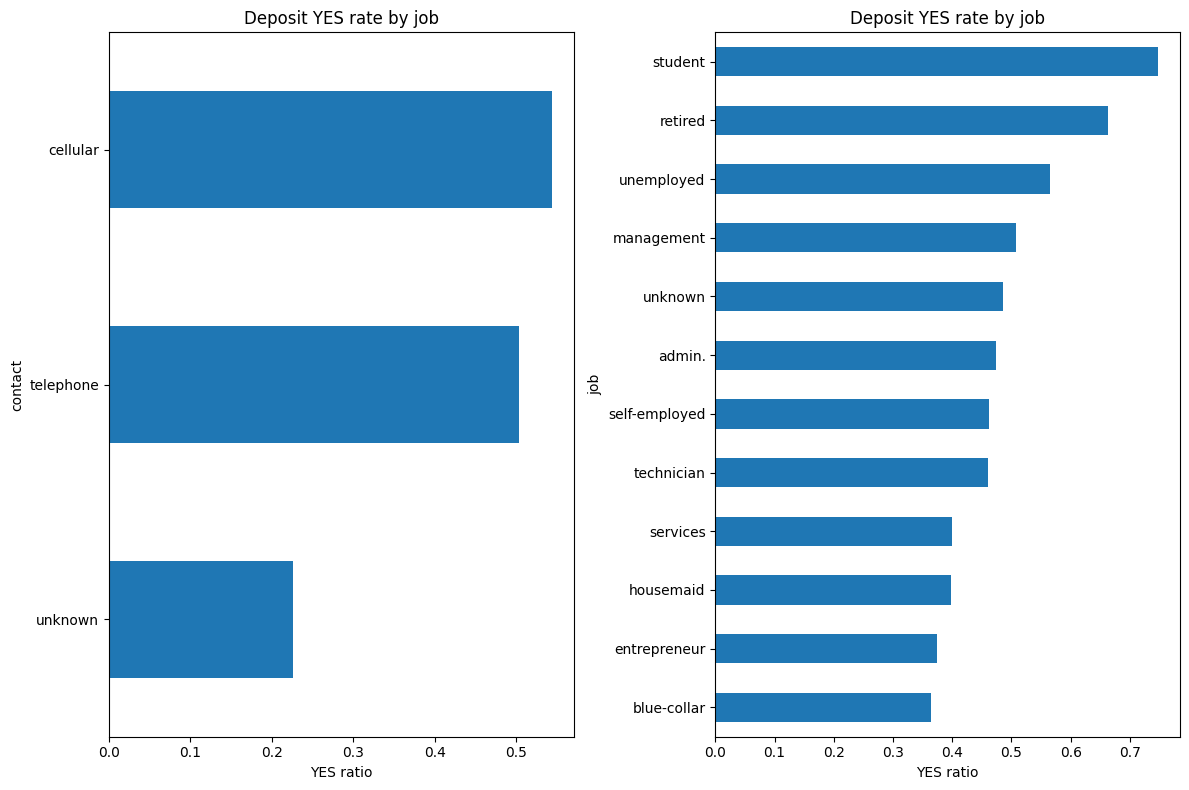

In [9]:
fig , ax = plt.subplots(1,2,figsize =(12,8))
contact_dis['yes'].sort_values().plot(kind='barh', title='Deposit YES rate by job',ax=ax[0])
job_dis['yes'].sort_values().plot(kind='barh', title='Deposit YES rate by job',ax=ax[1])
ax[0].set_xlabel('YES ratio')
ax[1].set_xlabel('YES ratio')
plt.tight_layout()
plt.show()

# handling missing data

In [10]:
unknown_cols = []
for i in df.columns:
    if 'unknown' in df[i].unique():
        unknown_cols.append(i)
unknown_cols

['job', 'education', 'contact', 'poutcome']

In [11]:
df_2 = df.copy()
for j in unknown_cols:
    df_2[j] = df_2[j].replace('unknown',np.nan)
df_2.isna().sum().sort_values(ascending=False)

poutcome     8326
contact      2346
education     497
job            70
month           0
previous        0
pdays           0
campaign        0
duration        0
age             0
day             0
loan            0
housing         0
balance         0
default         0
marital         0
deposit         0
dtype: int64

In [12]:
df_clean = df_2.copy()
df_clean = df_clean.drop(['poutcome'],axis=1)
df_clean ['contact'] = df_clean['contact'].fillna('unknown_contact')
df_clean['education'] = df_clean['education'].fillna(df_clean['education'].mode()[0])
df_clean['job'] = df_clean['job'].fillna(df_clean['job'].mode()[0])
df_clean.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
deposit      0
dtype: int64

In [13]:
X = df_clean.drop(['deposit','duration'],axis=1)
y = df_clean['deposit'].map({'yes':1,'no':0})

In [14]:
print('Deposit YES rate:', round(y.mean()*100,2), '%')

Deposit YES rate: 47.38 %


In [15]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']
Numerical columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


In [16]:
numerical_transformer = Pipeline(steps = [('scaler', StandardScaler())])
categorical_transfomer = Pipeline(steps=[('one_hot',OneHotEncoder(handle_unknown='ignore'))])


In [17]:
X['was_contacted_before'] = (X['pdays'] != -1).astype(int)

In [18]:
preprocessor = ColumnTransformer(transformers=[('num',numerical_transformer,num_cols),('cat',categorical_transfomer,cat_cols)]) 

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=42,stratify=y)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7813, 15)
Test shape: (3349, 15)


# define Grid For CV

In [20]:
def fit_grid(model_name, estimator, param_grid, scoring='f1', cv=5):
    pipe = Pipeline(steps=[('prep', preprocessor),('model', estimator)])

    grid = GridSearchCV(estimator=pipe,param_grid=param_grid,scoring=scoring,cv=cv,n_jobs=-1,return_train_score=True)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    res = {
        'model': model_name,
        'best_params': grid.best_params_,
        'cv_best_score': grid.best_score_,
        'train_score_at_best': grid.cv_results_['mean_train_score'][grid.best_index_],
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred)
    }
    return grid, res

# SVM

In [21]:
results = []
grids = {}
svm_linear = SVC(kernel='linear')
param_linear = {
    'model__C': [0.1, 1, 10]
}
grid_lin, res_lin = fit_grid('SVM-linear', svm_linear, param_linear, scoring='f1', cv=5)
grids['SVM-linear'] = grid_lin
results.append(res_lin)

svm_rbf = SVC(kernel='rbf')
param_rbf = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.1, 1]
}
grid_rbf, res_rbf = fit_grid('SVM-RBF', svm_rbf, param_rbf, scoring='f1', cv=5)
grids['SVM-RBF'] = grid_rbf
results.append(res_rbf)

svm_poly = SVC(kernel='poly')
param_poly = {
    'model__C': [0.1, 1, 10],
    'model__degree': [2, 3, 4, 5],
    'model__gamma': ['scale', 0.01, 0.1]
}
grid_poly, res_poly = fit_grid('SVM-poly', svm_poly, param_poly, scoring='f1', cv=5)
grids['SVM-poly'] = grid_poly
results.append(res_poly)


# Random Forest

In [22]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
param_rf = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 6, 12],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}
grid_rf, res_rf = fit_grid('RandomForest', rf, param_rf, scoring='f1', cv=5)
grids['RandomForest'] = grid_rf
results.append(res_rf)


# Gradient Boosting

In [23]:
gb = GradientBoostingClassifier(random_state=42)
param_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3]  
}

grid_gb, res_gb = fit_grid('GradientBoosting', gb, param_gb, scoring='f1', cv=5)
grids['GradientBoosting'] = grid_gb
results.append(res_gb)

# بهترین ها 

In [24]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='test_f1', ascending=False).reset_index(drop=True)
pd.set_option('display.max_colwidth', None)
results_df

,model,best_params,cv_best_score,train_score_at_best,test_accuracy,test_f1
0,GradientBoosting,"{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}",0.692565,0.732741,0.736041,0.686080
1,RandomForest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}",0.700129,0.888896,0.722305,0.680632
2,SVM-RBF,"{'model__C': 1, 'model__gamma': 0.1}",0.673893,0.717853,0.723798,0.663024
3,SVM-poly,"{'model__C': 1, 'model__degree': 3, 'model__gamma': 'scale'}",0.674335,0.719384,0.718722,0.656956
4,SVM-linear,{'model__C': 0.1},0.645333,0.653106,0.684682,0.637860


# سه تا از بهترین ها از هر نوع 

In [25]:
def top3_from_grid(grid, model_name):
    cvres = pd.DataFrame(grid.cv_results_)
    top3 = (cvres.sort_values('mean_test_score', ascending=False)
                 .head(3)[['params','mean_train_score','mean_test_score','rank_test_score']])
    top3.insert(0, 'model', model_name)
    return top3

top3_table = pd.concat([
    top3_from_grid(grids['SVM-linear'], 'SVM-linear'),
    top3_from_grid(grids['SVM-RBF'], 'SVM-RBF'),
    top3_from_grid(grids['SVM-poly'], 'SVM-poly'),
    top3_from_grid(grids['RandomForest'], 'RandomForest'),
    top3_from_grid(grids['GradientBoosting'], 'GradientBoosting'),
], ignore_index=True)

pd.set_option('display.max_colwidth', None)
top3_table

,model,params,mean_train_score,mean_test_score,rank_test_score
0,SVM-linear,{'model__C': 0.1},0.653106,0.645333,1
1,SVM-linear,{'model__C': 1},0.646373,0.637724,2
2,SVM-linear,{'model__C': 10},0.646191,0.637130,3
3,SVM-RBF,"{'model__C': 1, 'model__gamma': 0.1}",0.717853,0.673893,1
4,SVM-RBF,"{'model__C': 1, 'model__gamma': 'scale'}",0.705342,0.670434,2
5,SVM-RBF,"{'model__C': 1, 'model__gamma': 1}",0.949229,0.669587,3
6,SVM-poly,"{'model__C': 1, 'model__degree': 3, 'model__gamma': 'scale'}",0.719384,0.674335,1
7,SVM-poly,"{'model__C': 1, 'model__degree': 3, 'model__gamma': 0.1}",0.739127,0.671380,2
8,SVM-poly,"{'model__C': 1, 'model__degree': 4, 'model__gamma': 'scale'}",0.748531,0.666951,3
9,RandomForest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}",0.888896,0.700129,1


# نمودار دقت 

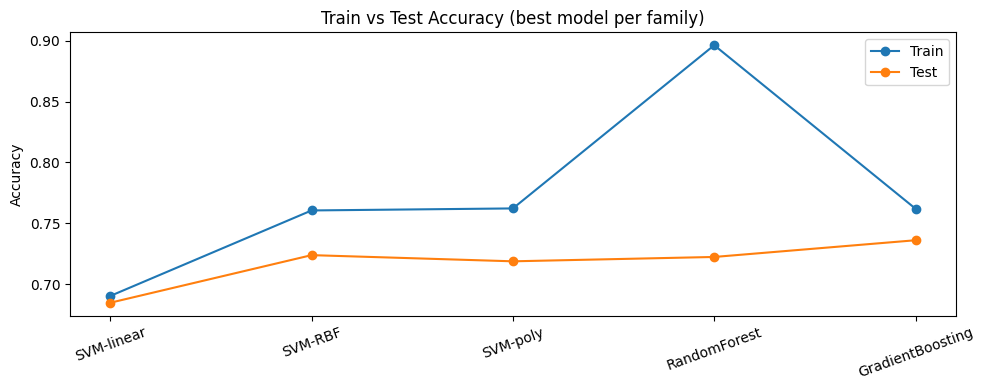

In [26]:
labels, train_acc, test_acc = [], [], []

for name, g in grids.items():
    best_pipe = g.best_estimator_
    labels.append(name)
    train_acc.append(accuracy_score(y_train, best_pipe.predict(X_train)))
    test_acc.append(accuracy_score(y_test, best_pipe.predict(X_test)))

plt.figure(figsize=(10,4))
plt.plot(labels, train_acc, marker='o')
plt.plot(labels, test_acc, marker='o')
plt.xticks(rotation=20)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy (best model per family)')
plt.legend(['Train', 'Test'])
plt.tight_layout()
plt.show()


# نمودار حساسیت به درجه 

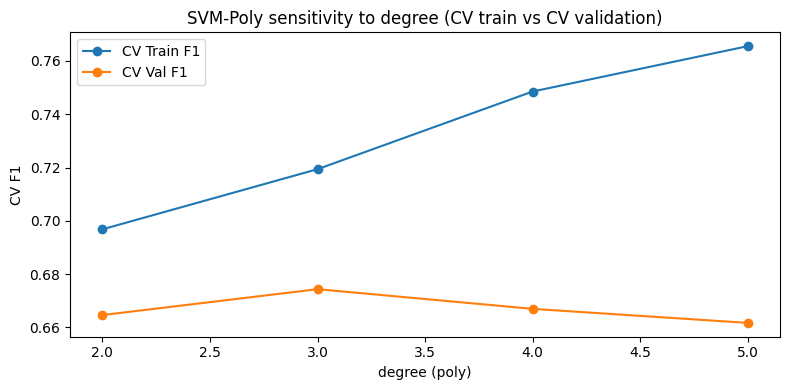

,degree,mean_train_score,mean_test_score,params
26,2,0.696804,0.664619,"{'model__C': 10, 'model__degree': 2, 'model__gamma': 0.1}"
15,3,0.719384,0.674335,"{'model__C': 1, 'model__degree': 3, 'model__gamma': 'scale'}"
18,4,0.748531,0.666951,"{'model__C': 1, 'model__degree': 4, 'model__gamma': 'scale'}"
21,5,0.765554,0.661684,"{'model__C': 1, 'model__degree': 5, 'model__gamma': 'scale'}"


In [28]:
poly_cv = pd.DataFrame(grids['SVM-poly'].cv_results_)
poly_cv['degree'] = poly_cv['param_model__degree'].astype(int)

best_by_degree = (poly_cv
                  .sort_values('mean_test_score', ascending=False)
                  .groupby('degree', as_index=False)
                  .head(1)
                  .sort_values('degree'))

plt.figure(figsize=(8,4))
plt.plot(best_by_degree['degree'], best_by_degree['mean_train_score'], marker='o')
plt.plot(best_by_degree['degree'], best_by_degree['mean_test_score'], marker='o')
plt.xlabel('degree (poly)')
plt.ylabel('CV F1')
plt.title('SVM-Poly sensitivity to degree (CV train vs CV validation)')
plt.legend(['CV Train F1', 'CV Val F1'])
plt.tight_layout()
plt.show()
best_by_degree[['degree', 'mean_train_score', 'mean_test_score', 'params']]


# انالیز جنگل تصمیم 

In [29]:
rf_cv = pd.DataFrame(grids['RandomForest'].cv_results_)
cols_show = [
    'param_model__max_depth', 'param_model__min_samples_split', 'param_model__min_samples_leaf',
    'mean_train_score', 'mean_test_score'
]
rf_cv_small = rf_cv[cols_show].sort_values('mean_test_score', ascending=False)
rf_cv_small

,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_train_score,mean_test_score
2,None,10,1,0.888896,0.700129
3,None,10,1,0.888060,0.700044
1,None,2,1,1.000000,0.695327
0,None,2,1,1.000000,0.693991
18,12,10,1,0.772999,0.690682
4,None,2,5,0.790609,0.689576
6,None,10,5,0.790609,0.689576
16,12,2,1,0.814860,0.688851
19,12,10,1,0.774070,0.688306
5,None,2,5,0.790849,0.687272


# جدول کوچکتر از برترین ها 

In [30]:
final_results = results_df.copy()
final_results = final_results[['model','best_params','test_accuracy','test_f1']].sort_values(by='test_f1', ascending=False)
final_results

,model,best_params,test_accuracy,test_f1
0,GradientBoosting,"{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}",0.736041,0.686080
1,RandomForest,"{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}",0.722305,0.680632
2,SVM-RBF,"{'model__C': 1, 'model__gamma': 0.1}",0.723798,0.663024
3,SVM-poly,"{'model__C': 1, 'model__degree': 3, 'model__gamma': 'scale'}",0.718722,0.656956
4,SVM-linear,{'model__C': 0.1},0.684682,0.637860


# ویژگی های مهم 

In [31]:
def get_tree_feature_importance(grid, model_name):
    best_pipe = grid.best_estimator_
    model = best_pipe.named_steps['model']
    prep = best_pipe.named_steps['prep']

    feature_names = prep.get_feature_names_out()
    importances = model.feature_importances_

    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    return df_imp
rf_imp = get_tree_feature_importance(grids['RandomForest'], 'RandomForest')
gb_imp = get_tree_feature_importance(grids['GradientBoosting'], 'GradientBoosting')

In [32]:
rf_imp.head(10)

,feature,importance
1,num__balance,0.132154
0,num__age,0.111764
2,num__day,0.101640
4,num__pdays,0.068626
3,num__campaign,0.055396
5,num__previous,0.045367
31,cat__contact_unknown_contact,0.044061
29,cat__contact_cellular,0.028812
26,cat__housing_yes,0.028126
25,cat__housing_no,0.025075


In [33]:
gb_imp.head(10)

,feature,importance
31,cat__contact_unknown_contact,0.162216
4,num__pdays,0.154568
0,num__age,0.084862
1,num__balance,0.084648
2,num__day,0.081035
26,cat__housing_yes,0.042277
25,cat__housing_no,0.040418
39,cat__month_mar,0.035817
32,cat__month_apr,0.033432
3,num__campaign,0.032899


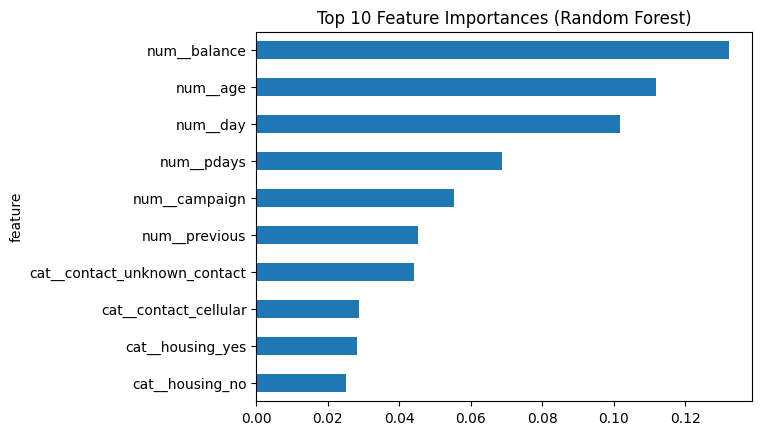

In [34]:
rf_imp.head(10).plot(kind='barh',x='feature',y='importance',title='Top 10 Feature Importances (Random Forest)',legend=False)
plt.gca().invert_yaxis()
plt.show()


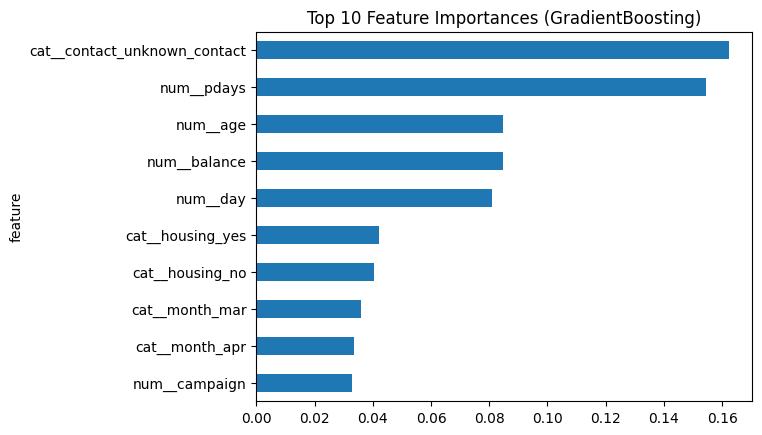

In [35]:
gb_imp.head(10).plot(kind='barh',x='feature',y='importance',title='Top 10 Feature Importances (GradientBoosting)',legend=False)
plt.gca().invert_yaxis()
plt.show()


# ضرایب خطی 

In [36]:
def get_svm_linear_coef(grid):
    best_pipe = grid.best_estimator_
    model = best_pipe.named_steps['model']
    prep = best_pipe.named_steps['prep']

    feature_names = prep.get_feature_names_out()
    coef = model.coef_[0]

    df_coef = pd.DataFrame({
        'feature': feature_names,
        'coef': coef
    })

    df_coef['abs_coef'] = df_coef['coef'].abs()
    return df_coef.sort_values(by='abs_coef', ascending=False)

svm_coef = get_svm_linear_coef(grids['SVM-linear'])
svm_coef


,feature,coef,abs_coef
36,cat__month_jan,-0.905584,0.905584
39,cat__month_mar,0.800000,0.800000
41,cat__month_nov,-0.752810,0.752810
42,cat__month_oct,0.664452,0.664452
14,cat__job_student,0.656170,0.656170
33,cat__month_aug,-0.635758,0.635758
31,cat__contact_unknown_contact,-0.601637,0.601637
34,cat__month_dec,0.600000,0.600000
37,cat__month_jul,-0.581110,0.581110
43,cat__month_sep,0.539096,0.539096
